In [7]:
import os
import cv2
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from preprocess import Extractor

In [8]:
# instance of extractor
extractor = Extractor()
extractor.load_model()

# affect color feature

# 1. original

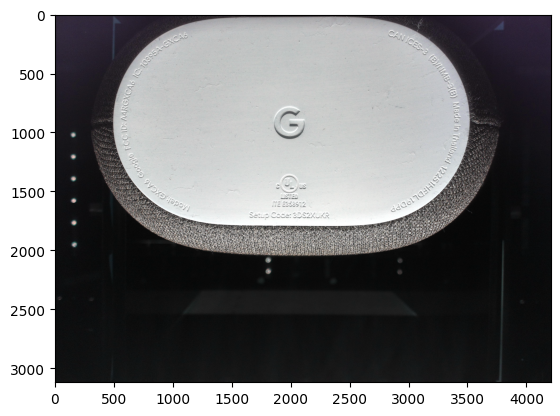

In [12]:
# read random image
dir = "samples/org"
# path = random.choice(os.listdir(dir))
img = cv2.imread("Google Nest Audio.jpg")
plt.imshow(img)

(3104, 4192)


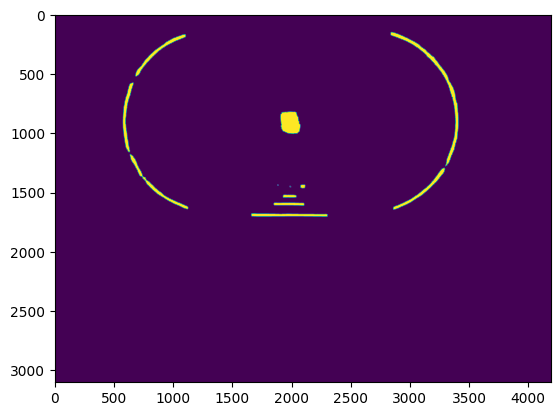

In [14]:
# extract mask
mask = extractor.get_mask(img)
print(mask.shape)
plt.imshow(mask)

# 1. grey

Text(0.5, 1.0, 'grey_27.jpg')

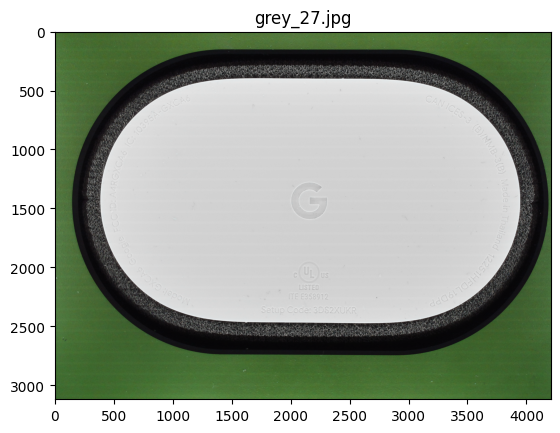

In [85]:
# read random image
dir = "samples/grey"
path = random.choice(os.listdir(dir))
img = cv2.imread(os.path.join(dir,path))
plt.imshow(img)
plt.title(path)

(3104, 4192)


Text(0.5, 1.0, 'grey_27.jpg')

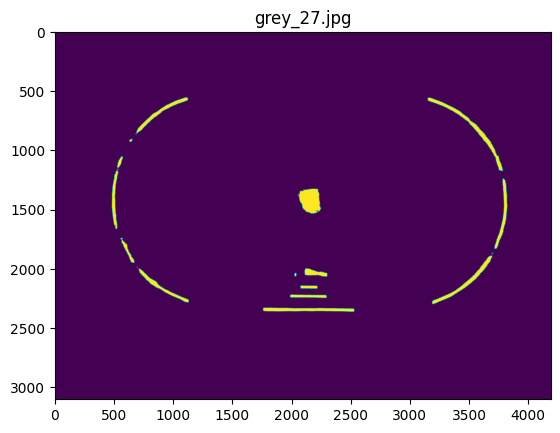

In [86]:
# extract mask
mask = extractor.get_mask(img)
print(mask.shape)
plt.imshow(mask)
plt.title(path)

# 2. blue

Text(0.5, 1.0, 'blue_67.jpg')

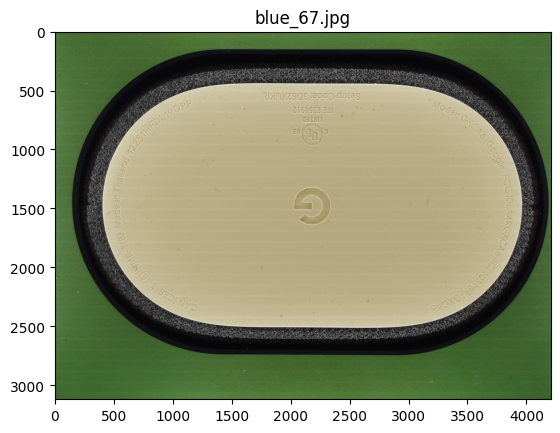

In [87]:
# read random image
dir = "samples/blue"
path = random.choice(os.listdir(dir))
img = cv2.imread(os.path.join(dir,path))
plt.imshow(img)
plt.title(path)

(3104, 4192)


Text(0.5, 1.0, 'blue_67.jpg')

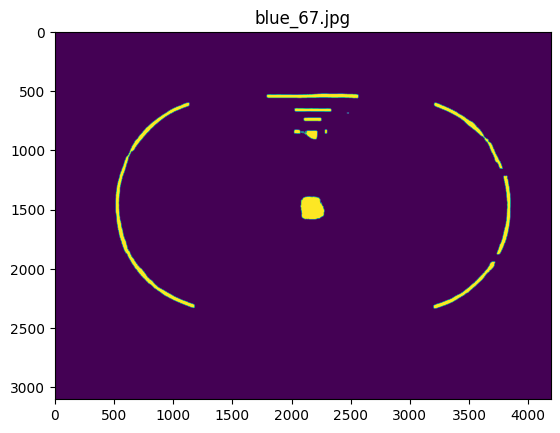

In [88]:
# extract mask
mask = extractor.get_mask(img)
print(mask.shape)
plt.imshow(mask)
plt.title(path)

# 3.green

Text(0.5, 1.0, 'green_60.jpg')

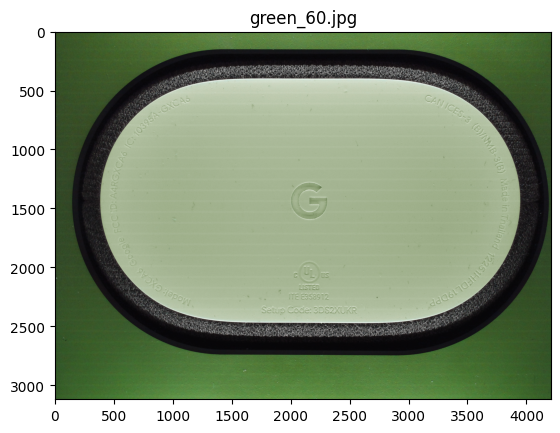

In [89]:
# read random image
dir = "samples/green"
path = random.choice(os.listdir(dir))
img = cv2.imread(os.path.join(dir,path))
plt.imshow(img)
plt.title(path)

(3104, 4192)


Text(0.5, 1.0, 'green_60.jpg')

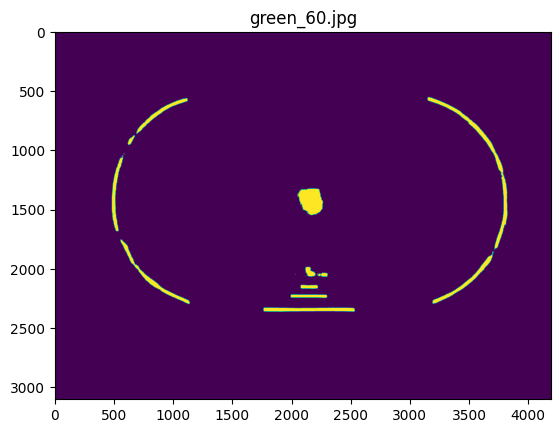

In [90]:
# extract mask
mask = extractor.get_mask(img)
print(mask.shape)
plt.imshow(mask)
plt.title(path)

# 4.pink

Text(0.5, 1.0, 'pink_60.jpg')

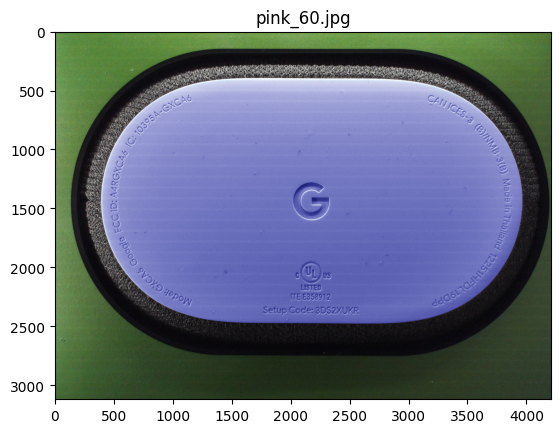

In [190]:
# read random image
dir = "samples/pink"
path = random.choice(os.listdir(dir))
img = cv2.imread(os.path.join(dir,path))
plt.imshow(img)
plt.title(path)

(3104, 4192)


Text(0.5, 1.0, 'pink_60.jpg')

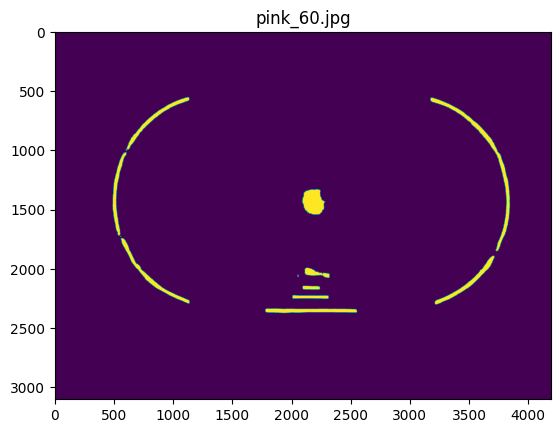

In [191]:
# extract mask
mask = extractor.get_mask(img)
print(mask.shape)
plt.imshow(mask)
plt.title(path)

In [192]:
# find contours
contours, hierarchy = cv2.findContours(mask.astype("uint8"), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
print(f"number of contours: {len(contours)}")

number of contours: 84


Text(0.5, 1.0, 'pink_60.jpg')

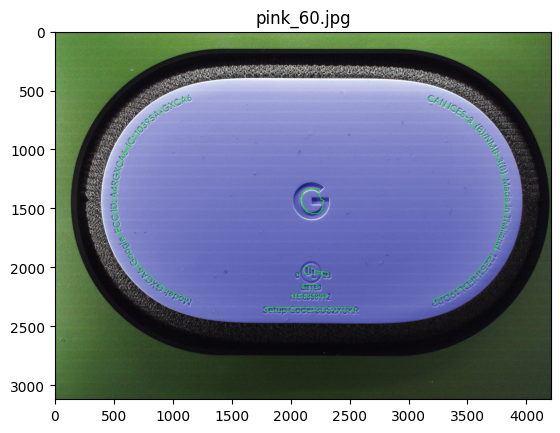

In [193]:
img = cv2.drawContours(img,contours, -1, (0,255,0), 3)
plt.imshow(img)
plt.title(path)

boxs 84


Text(0.5, 1.0, 'pink_60.jpg')

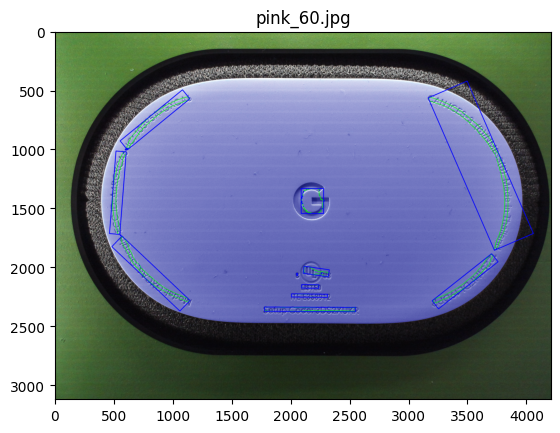

In [194]:
boxs = []

for cnt in contours:
    rect = cv2.minAreaRect(cnt)
    box = cv2.boxPoints(rect)
    box = np.int0(box)
    boxs.append(box)
    cv2.drawContours(img,[box],0,(0,0,255),6)

print(f"boxs {len(boxs)}")
plt.imshow(img)
plt.title(path)
#cv2.imwrite("rr.jpg",img)

# read image

# detect rr (rotated rectangle)

In [1]:
import os
import cv2
import sys
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from preprocess import Extractor

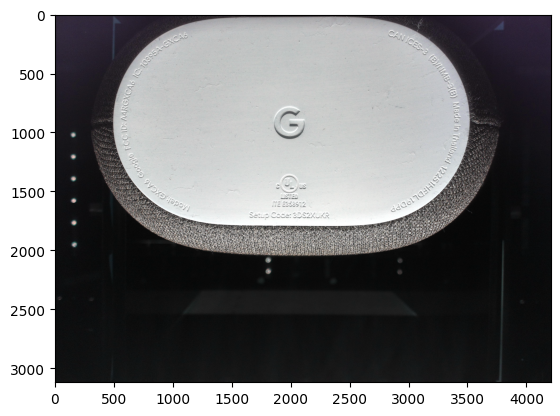

In [2]:
dir = "samples/org"
img_org = cv2.imread("Google Nest Audio.jpg")
img = img_org.copy()
plt.imshow(img)

In [3]:
# instance of extractor
extractor = Extractor()
extractor.load_model()

(3104, 4192)


/home/greystone/locchuong/ocr-exp/pre/pre_post_processing.py:115: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  xmin = np.clip(np.floor(box[:, 0].min()).astype(np.int), 0, w - 1)
/home/greystone/locchuong/ocr-exp/pre/pre_post_processing.py:116: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your curren

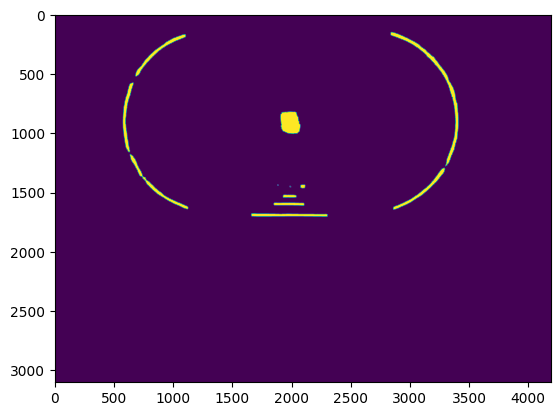

In [4]:
# extract mask
mask = extractor.get_mask(img)
print(mask.shape)
plt.imshow(mask)

In [5]:
# find contours
contours, hierarchy = cv2.findContours(mask.astype("uint8"), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
print(f"number of contours: {len(contours)}")

number of contours: 47


In [6]:
# select suitable area
areas = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    areas.append(area)

In [7]:
print(areas)

[13026.0, 5077.0, 2268.5, 1.5, 29.5, 1.0, 1.0, 2.5, 0.0, 970.0, 26.5, 13533.5, 5.0, 0.0, 15273.0, 6.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 25737.5, 7.0, 2.0, 5.5, 7.0, 7.0, 7.0, 2.0, 13.5, 6.0, 6.0, 6.0, 0.0, 0.0, 10.0, 14668.5, 0.0, 13721.0, 36064.0, 2.0, 2.0]


In [8]:
print(np.array(areas).mean())

2989.255319148936


In [9]:
# select suitable area
cnts = []
s_min = np.array(areas).mean()
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > s_min:
        cnts.append(cnt)

In [10]:
print(len(cnts))

8


8
boxs 8


Text(0.5, 1.0, 'greater then mean rotated rectangle')

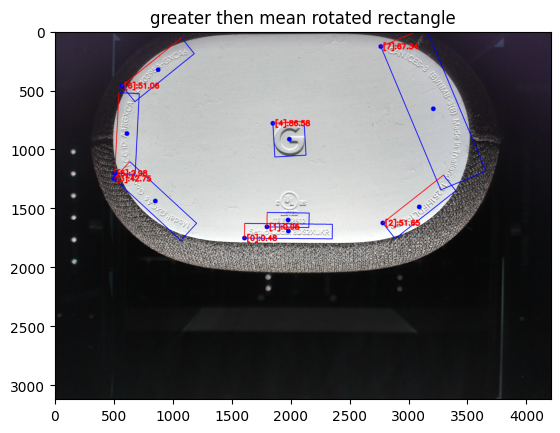

In [11]:
padding = 100
boxs = []
min_boxs = []
rects = []
angles = [] # degree
img = img_org.copy()
for i,cnt in enumerate(cnts):
    # maximum rect
    x,y,w,h = cv2.boundingRect(cnt)
    boxs.append((x,y,w,h))
    # roated rect (minimum rect)
    rect = cv2.minAreaRect(cnt)
    # angle
    angle = rect[-1]
    angles.append(angle)
    # new rect add padding
    h = int(rect[1][0]+ padding)
    w = int(rect[1][1]+ padding)
    new_rect = (rect[0],(h,w),angle) #h,w
    rects.append(new_rect)
    box = cv2.boxPoints(new_rect)
    box = np.int0(box)
    min_boxs.append(box)
    # draw
    #cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),6) # max rect
    cv2.drawContours(img,[box],0,(0,0,255),6) # min rect
    cv2.circle(img,(int(rect[0][0]),int(rect[0][1])),20,(0,0,255),-1)# top point
    cv2.circle(img,box[0],20,(0,0,255),-1)# top point
    cv2.line(img,box[0],box[1],(255,0,0),6)# top line
    cv2.putText(img,f"[{i}]:{round(angle,2)}",box[0]+np.array([20,20]),cv2.FONT_HERSHEY_SIMPLEX,2,(255,0,0),10, cv2.LINE_AA) # angle

print(len(min_boxs))
print(f"boxs {len(min_boxs)}")
plt.imshow(img)
plt.title("greater then mean rotated rectangle")
#cv2.imwrite("img.jpg",img)

In [12]:
box

array([[2758,  131],
       [3140,  -28],
       [3648, 1187],
       [3266, 1347]])

In [13]:
rect

((3203.603515625, 659.5841064453125),
 (1218.2274169921875, 314.21575927734375),
 67.33592987060547)

In [14]:
angles

[0.4830895662307739,
 0.9548413157463074,
 51.65054702758789,
 42.74542999267578,
 86.58341979980469,
 2.9814610481262207,
 51.05898666381836,
 67.33592987060547]

In [15]:
boxs

[(1655, 1682, 644, 27),
 (1845, 1591, 257, 26),
 (2853, 1298, 437, 352),
 (632, 1181, 491, 465),
 (1900, 825, 170, 186),
 (573, 579, 89, 585),
 (677, 171, 426, 354),
 (2831, 153, 572, 1127)]

In [16]:
box.shape

(4, 2)

In [17]:
# find center of rec
print(box[0]+box[2])
print(box[1]+box[3])

[6406 1318]
[6406 1319]


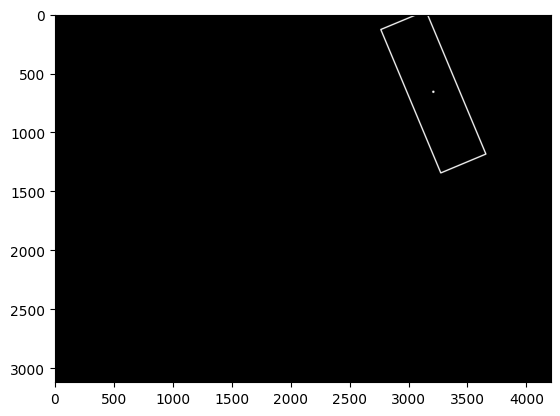

In [18]:
avg = (box[0]+box[2])/2
cx = int(avg[0])
cy = int(avg[1])

blank = np.zeros_like(img)
# display result
cv2.polylines(blank, [box.reshape(-1,1,2)],True,(255,255,255),10)
cv2.circle(blank,(cx,cy),10,(255,255,255),-1)
plt.imshow(blank)

# select rr

In [19]:
img_org.shape

(3120, 4208, 3)

In [20]:
blank = np.zeros_like(img_org)
blank.shape

(3120, 4208, 3)

# rotate and crop

In [21]:
def rotateAndScale(img, scaleFactor = 0.5, degreesCCW = 30):
    '''
    rotate image with no cut out vertices
    Args:
        img: original image
        scaleFactor: scale of output image
        degreesCCW: angle (degrees)
    Return:
        rotateImg: rotated image
        M: rotate matrix
    '''
    h,w,c = img.shape #note: numpy uses (y,x) convention but most OpenCV functions use (x,y)
    M = cv2.getRotationMatrix2D(center=(w/2,h/2), angle=degreesCCW, scale=scaleFactor) #rotate about center of image.

    #choose a new image size.
    new_w,new_h = w*scaleFactor,h*scaleFactor
    #include this if you want to prevent corners being cut off
    r = np.deg2rad(degreesCCW)
    new_w,new_h = (abs(np.sin(r)*new_h) + abs(np.cos(r)*new_w),abs(np.sin(r)*new_w) + abs(np.cos(r)*new_h))

    #the warpAffine function call, below, basically works like this:
    # 1. apply the M transformation on each pixel of the original image
    # 2. save everything that falls within the upper-left "dsize" portion of the resulting image.

    #So I will find the translation that moves the result to the center of that region.
    (tx,ty) = ((new_w-w)/2,(new_h-h)/2)
    M[0,2] += tx #third column of matrix holds translation, which takes effect after rotation.
    M[1,2] += ty

    rotatedImg = cv2.warpAffine(img, M, dsize=(int(new_w),int(new_h)))
    return rotatedImg,M

In [22]:
def calc_dist(pt1,pt2):
    '''
    Calculate distance of 2 point
    Args:
        pt1: first point
        pt2: second point
    Return:
        dist: distance
    '''
    dist = cv2.norm(pt1-pt2)
    return dist

In [23]:
for i,t in enumerate(angles):
    # original input
    img = img_org.copy()
    img_blank = np.zeros_like(img_org)
    
    # draw
    rect = rects[i]
    box = min_boxs[i] # 4 pts form of rect
    rebox = box.reshape(-1,1,2)
    
    #cv2.drawContours(img,[box],0,(0,0,255),6) # min rect
    #cv2.circle(img,box[0],20,(0,0,255),-1)# top point
    #cv2.line(img,box[0],box[1],(255,0,0),6)# top line
    #cv2.putText(img,f"[{i}]:{round(angle,2)}",box[0]+np.array([20,20]),cv2.FONT_HERSHEY_SIMPLEX,2,(255,0,0),10, cv2.LINE_AA) # angle
    
    #rotate
    img,M = rotateAndScale(img, scaleFactor = 2.0, degreesCCW = t)
    img_blank,_ = rotateAndScale(img_blank, scaleFactor = 2.0, degreesCCW = t)
    rebox = cv2.transform(rebox, M) # what you need
    
    # find new top left,bottom right
    dist = []
    for pt in rebox.reshape(-1,2):
        d = calc_dist(np.array([0,0]),pt)
        dist.append(d)
    top_left = rebox.reshape(-1,2)[np.argmin(dist)]
    bottom_right = rebox.reshape(-1,2)[np.argmax(dist)]
    w,h = bottom_right - top_left
    x,y = top_left
    img_blank = img[ y:y+h, x:x+w ]
    
    cv2.drawContours(img,[rebox],0,(0,0,255),6) # min rect
    cv2.circle(img,top_left,20,(0,0,255),-1) # top point
    cv2.circle(img,bottom_right,20,(0,0,255),-1) # top point
    
    #cv2.rectangle(img, top_left, top_left+np.array([w,h]),(0,0,255),10)
    cv2.imwrite(f"img_{i}.jpg",img_blank)
    print(rebox,"\n\n")

[[[3237 3554]]

 [[3237 3306]]

 [[4723 3307]]

 [[4724 3555]]] 


[[[3643 3400]]

 [[3643 3156]]

 [[4355 3154]]

 [[4353 3400]]] 


[[[5995 4267]]

 [[5996 2957]]

 [[6334 2959]]

 [[6334 4267]]] 


[[[2431 6872]]

 [[2432 6479]]

 [[3974 6479]]

 [[3974 6874]]] 


[[[1781 4813]]

 [[1781 4284]]

 [[2354 4284]]

 [[2354 4813]]] 


[[[1136 2794]]

 [[1135 1424]]

 [[1479 1424]]

 [[1481 2794]]] 


[[[1435 6247]]

 [[1435 4952]]

 [[1781 4953]]

 [[1782 6247]]] 


[[[2367 2777]]

 [[2368 1949]]

 [[5002 1948]]

 [[5003 2777]]] 




In [24]:
box.shape

(4, 2)

In [25]:
box

array([[2758,  131],
       [3140,  -28],
       [3648, 1187],
       [3266, 1347]])

In [26]:
box_ = box.reshape(-1,1,2)
box_

array([[[2758,  131]],

       [[3140,  -28]],

       [[3648, 1187]],

       [[3266, 1347]]])

In [27]:
rbox = cv2.transform(box_, M) # what you need
rbox

array([[[2367, 2777]],

       [[2368, 1949]],

       [[5002, 1948]],

       [[5003, 2777]]], dtype=int32)

In [28]:
rbox.reshape(-1,2)

array([[2367, 2777],
       [2368, 1949],
       [5002, 1948],
       [5003, 2777]], dtype=int32)

In [29]:
calc_dist(np.array([0,0]),rbox[0])

3648.8927087542597

In [30]:
calc_dist(np.array([0,0]),rbox[1])

3066.924355115398

In [31]:
dist = []
for pt in rbox:
    d = calc_dist(np.array([0,0]),pt)
    dist.append(d)
    
np.argmin(dist)

1

# extract roi function

In [61]:
import os
import cv2
import sys
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from preprocess import Extractor

In [62]:
# instance of extractor
extractor = Extractor()
extractor.load_model()

In [63]:
def rotateAndScale(img, scaleFactor = 0.5, degreesCCW = 30):
    '''
    rotate image with no cut out vertices
    Args:
        img: original image
        scaleFactor: scale of output image
        degreesCCW: angle (degrees)
    Return:
        rotateImg: rotated image
        M: rotate matrix
    '''
    h,w,c = img.shape #note: numpy uses (y,x) convention but most OpenCV functions use (x,y)
    M = cv2.getRotationMatrix2D(center=(w/2,h/2), angle=degreesCCW, scale=scaleFactor) #rotate about center of image.

    #choose a new image size.
    new_w,new_h = w*scaleFactor,h*scaleFactor
    #include this if you want to prevent corners being cut off
    r = np.deg2rad(degreesCCW)
    new_w,new_h = (abs(np.sin(r)*new_h) + abs(np.cos(r)*new_w),abs(np.sin(r)*new_w) + abs(np.cos(r)*new_h))

    #the warpAffine function call, below, basically works like this:
    # 1. apply the M transformation on each pixel of the original image
    # 2. save everything that falls within the upper-left "dsize" portion of the resulting image.

    #So I will find the translation that moves the result to the center of that region.
    (tx,ty) = ((new_w-w)/2,(new_h-h)/2)
    M[0,2] += tx #third column of matrix holds translation, which takes effect after rotation.
    M[1,2] += ty

    rotatedImg = cv2.warpAffine(img, M, dsize=(int(new_w),int(new_h)))
    return rotatedImg,M

In [64]:
def calc_dist(pt1,pt2):
    '''
    Calculate distance of 2 point
    Args:
        pt1: first point
        pt2: second point
    Return:
        dist: distance
    '''
    dist = cv2.norm(pt1-pt2)
    return dist

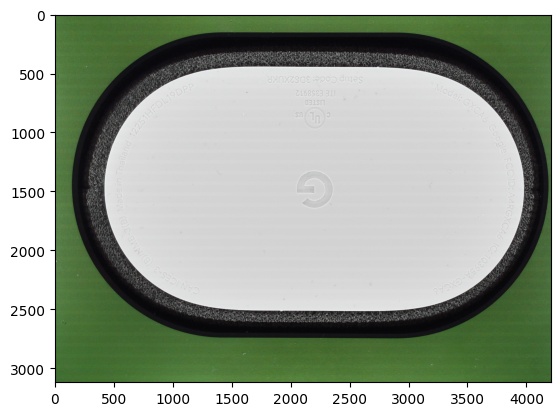

In [114]:
path = "samples/grey"
file = random.choice(os.listdir(path))
img_org = cv2.imread(os.path.join(path,file))
img = img_org.copy()
plt.imshow(img)

In [115]:
# extract mask
mask = extractor.get_mask(img)

In [116]:
# find contours
contours, hierarchy = cv2.findContours(mask.astype("uint8"), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

In [117]:
# select suitable area
areas = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    areas.append(area)

In [118]:
# select suitable area
cnts = []
s_min = np.array(areas).mean()
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > s_min:
        cnts.append(cnt)

(3104, 4192, 3)


True

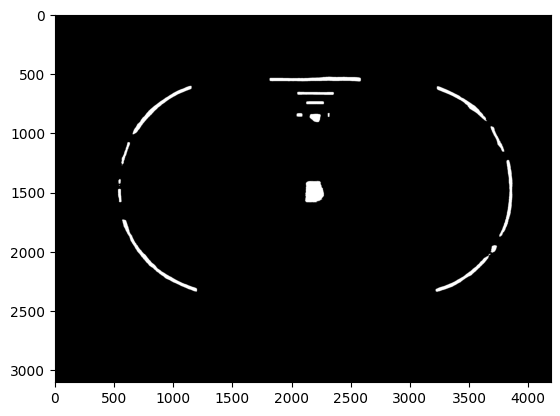

In [119]:
merged = cv2.merge([mask, mask, mask])
print(merged.shape)
plt.imshow(merged)
cv2.imwrite("merged.jpg",merged)

14
boxs 14


Text(0.5, 1.0, 'greater then mean rotated rectangle')

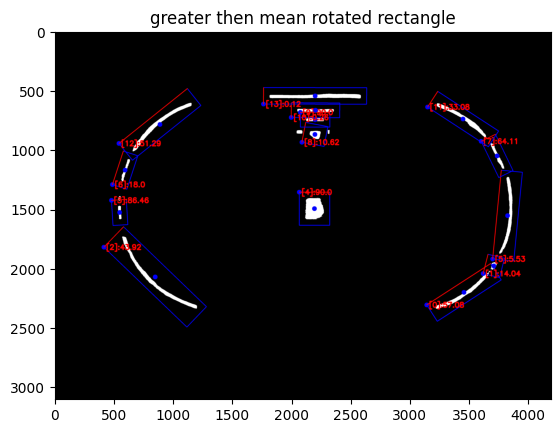

In [120]:
padding = 100
boxs = []
min_boxs = []
rects = []
angles = [] # degree
img = merged#img_org.copy()

for i,cnt in enumerate(cnts):
    # maximum rect
    x,y,w,h = cv2.boundingRect(cnt)
    boxs.append((x,y,w,h))
    # roated rect (minimum rect)
    rect = cv2.minAreaRect(cnt)
    # angle
    angle = rect[-1]
    angles.append(angle)
    # new rect add padding
    h = int(rect[1][0]+ padding)
    w = int(rect[1][1]+ padding)
    new_rect = (rect[0],(h,w),angle) #h,w
    rects.append(new_rect)
    box = cv2.boxPoints(new_rect)
    box = np.int0(box)
    min_boxs.append(box)
    # draw
    #cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),6) # max rect
    cv2.drawContours(img,[box],0,(0,0,255),6) # min rect
    cv2.circle(img,(int(rect[0][0]),int(rect[0][1])),20,(0,0,255),-1)# top point
    cv2.circle(img,box[0],20,(0,0,255),-1)# top point
    cv2.line(img,box[0],box[1],(255,0,0),6)# top line
    cv2.putText(img,f"[{i}]:{round(angle,2)}",box[0]+np.array([20,20]),cv2.FONT_HERSHEY_SIMPLEX,2,(255,0,0),10, cv2.LINE_AA) # angle

print(len(min_boxs))
print(f"boxs {len(min_boxs)}")
plt.imshow(img)
plt.title("greater then mean rotated rectangle")
#cv2.imwrite("merged.jpg",img)

(3104, 4192, 3)


True

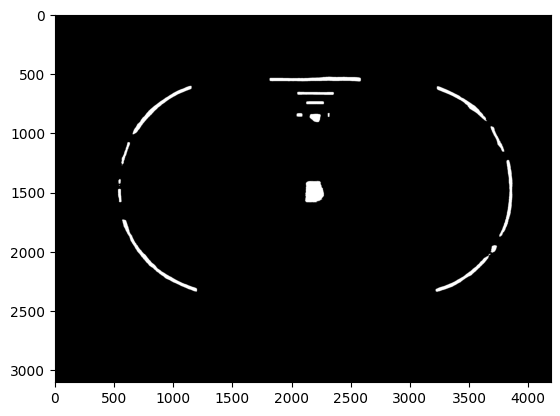

In [121]:
merged = cv2.merge([mask, mask, mask])
print(merged.shape)
plt.imshow(merged)
cv2.imwrite("merged.jpg",merged)

In [122]:
img_list = []
rois = []
rois_bin = []

for i,t in enumerate(angles):
    # original input
    img = img_org.copy()
    img_bin = cv2.imread("merged.jpg")
    # draw
    rect = rects[i]
    box = min_boxs[i] # 4 pts form of rect
    rebox = box.reshape(-1,1,2)

    #rotate
    img,M = rotateAndScale(img, scaleFactor = 2.0, degreesCCW = t)
    img_bin,_ = rotateAndScale(img_bin, scaleFactor = 2.0, degreesCCW = t)
    rebox = cv2.transform(rebox, M) # what you need
    
    # find new top left,bottom right
    dist = []
    for pt in rebox.reshape(-1,2):
        d = calc_dist(np.array([0,0]),pt)
        dist.append(d)
    top_left = rebox.reshape(-1,2)[np.argmin(dist)]
    bottom_right = rebox.reshape(-1,2)[np.argmax(dist)]
    w,h = bottom_right - top_left
    x,y = top_left
    out = img[y:y+h,x:x+w]
    out_bin = img_bin[y:y+h,x:x+w]
    rois.append(out)
    rois_bin.append(out_bin)
    
    cv2.drawContours(img,[rebox],0,(0,0,255),6) # min rect
    cv2.circle(img,top_left,20,(0,0,255),-1) # top point
    cv2.circle(img,bottom_right,20,(0,0,255),-1) # top point
    
    #cv2.rectangle(img, top_left, top_left+np.array([w,h]),(0,0,255),10)
    cv2.imwrite(f"img_{i}.jpg",out)
    img_list.append(f"img_{i}.jpg")
    
    print(f"img_{i}.jpg")
    #print(rebox,"\n\n")

img_0.jpg
img_1.jpg
img_2.jpg
img_3.jpg
img_4.jpg
img_5.jpg
img_6.jpg
img_7.jpg
img_8.jpg
img_9.jpg
img_10.jpg
img_11.jpg
img_12.jpg
img_13.jpg


In [125]:
for i,roi in enumerate(rois):
    h,w,c = roi.shape
    if h > w:
        roi = cv2.rotate(roi,cv2.ROTATE_90_CLOCKWISE)
        rois[i]=roi
    #print(f"h={h},w={w}")

In [126]:
for i,roi in enumerate(rois_bin):
    h,w,c = roi.shape
    if h > w:
        roi = cv2.rotate(roi,cv2.ROTATE_90_CLOCKWISE)
        rois_bin[i]=roi

<Figure size 640x480 with 0 Axes>

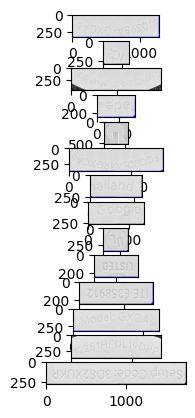

In [127]:
plt.figure()

fig,ax = plt.subplots(len(rois),1)
for i in range(len(rois)):
    ax[i].imshow(rois[i])
# plt.tight_layout()

<Figure size 640x480 with 0 Axes>

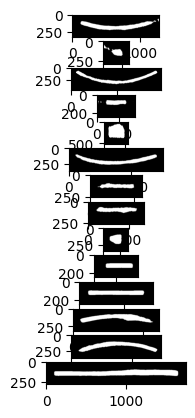

In [128]:
plt.figure()

fig,ax = plt.subplots(len(rois_bin),1)
for i in range(len(rois_bin)):
    ax[i].imshow(rois_bin[i])
# plt.tight_layout()

# find fit-in cycle

In [129]:
from circle_fit import taubinSVD

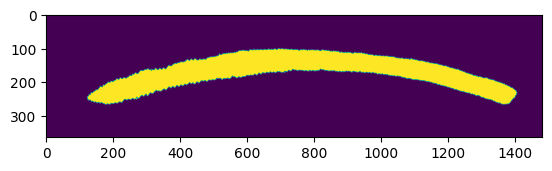

In [165]:
roi = rois_bin[-2]
roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
plt.imshow(roi)

In [166]:
h,w = roi.shape
print(f"h={h}, w= {w}")

h=365, w= 1480


In [167]:
roi.shape

(365, 1480)

In [168]:
list_point = []
for i in range(w):
    v_line = roi[0:h-1,i:i+1]
    pos = cv2.findNonZero(v_line)
    if pos is not None:
        list_point.append([pos[0][0][-1], i])

In [169]:
list_point

[[320, 0],
 [319, 1],
 [320, 2],
 [346, 3],
 [344, 4],
 [344, 5],
 [239, 111],
 [239, 112],
 [236, 113],
 [235, 114],
 [235, 115],
 [235, 116],
 [235, 117],
 [235, 118],
 [235, 119],
 [235, 120],
 [227, 121],
 [227, 122],
 [230, 123],
 [223, 124],
 [223, 125],
 [223, 126],
 [222, 127],
 [219, 128],
 [221, 129],
 [222, 130],
 [222, 131],
 [225, 132],
 [224, 133],
 [223, 134],
 [223, 135],
 [223, 136],
 [224, 137],
 [229, 138],
 [232, 139],
 [231, 140],
 [227, 141],
 [227, 142],
 [227, 143],
 [225, 144],
 [222, 145],
 [221, 146],
 [221, 147],
 [222, 148],
 [218, 149],
 [219, 150],
 [215, 151],
 [215, 152],
 [212, 153],
 [212, 154],
 [212, 155],
 [212, 156],
 [207, 157],
 [207, 158],
 [207, 159],
 [204, 160],
 [204, 161],
 [205, 162],
 [205, 163],
 [205, 164],
 [204, 165],
 [205, 166],
 [209, 167],
 [209, 168],
 [209, 169],
 [209, 170],
 [209, 171],
 [209, 172],
 [210, 173],
 [211, 174],
 [209, 175],
 [208, 176],
 [207, 177],
 [206, 178],
 [205, 179],
 [206, 180],
 [205, 181],
 [204, 182]

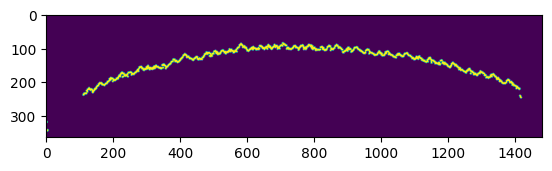

In [171]:
blank = np.zeros_like(roi)
for point in list_point:
    cv2.circle(blank, (point[1], point[0]), 3, (255), -1)
plt.imshow(blank)

In [135]:
xc, yc, r, sigma = taubinSVD(list_point)
print(f"xc={int(xc)}, yc={int(yc)}, sigma={sigma}")

xc=1795, yc=773, sigma=6.440229071189987


In [136]:
v_line.shape

(364, 1)

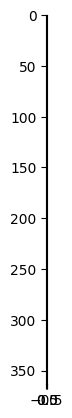

In [137]:
plt.imshow(v_line)

# polar to castesian

xc=1795, yc=773, sigma=6.440229071189987


Text(0.5, 1.0, 'xc=1795, yc=773,r= 1698.7990894719132, sigma=6.440229071189987')

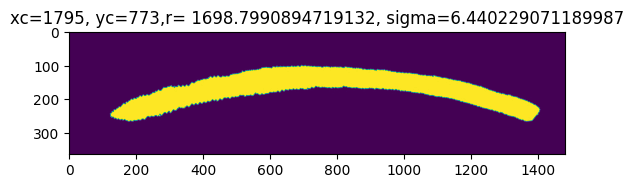

In [161]:
from circle_fit import taubinSVD

i = random.choice(range(len(rois)))
roi = rois_bin[i]
roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

list_point = []
for i in range(w):
    v_line = roi[0:h-1,i:i+1]
    pos = cv2.findNonZero(v_line)
    if pos is not None:
        list_point.append([pos[0][0][-1], i])
        
xc, yc, r, sigma = taubinSVD(list_point)
print(f"xc={int(xc)}, yc={int(yc)}, sigma={sigma}")

plt.imshow(roi)
plt.title(f"xc={int(xc)}, yc={int(yc)},r= {r}, sigma={sigma}")

# references

[warpPolar](https://docs.opencv.org/3.4.2/da/d54/group__imgproc__transform.html#ga49481ab24fdaa0ffa4d3e63d14c0d5e4)

[How to calculate the positions of new points after rotating the image around arbitrary axis](https://stackoverflow.com/questions/73484188/how-to-calculate-the-positions-of-new-points-after-rotating-the-image-around-arb)

[after-rotation-window-doesnt-fit-image](https://stackoverflow.com/questions/11764575/python-2-7-3-opencv-2-4-after-rotation-window-doesnt-fit-image)

[skew for ocr](https://stackoverflow.com/questions/57964634/python-opencv-skew-correction-for-ocr)

[How to straighten a rotated rectangle area of an image using OpenCV in Python?](https://stackoverflow.com/questions/11627362/how-to-straighten-a-rotated-rectangle-area-of-an-image-using-opencv-in-python)

[Order of corners in a rotating rectangle in OpenCV Python](https://stackoverflow.com/questions/69074165/order-of-corners-in-a-rotating-rectangle-in-opencv-python)

[rectangle formular](https://structx.com/Shape_Formulas_033.html)

[rotated rectangle](https://namkeenman.wordpress.com/2015/12/18/open-cv-determine-angle-of-rotatedrect-minarearect/)

[theailearner](https://theailearner.com/tag/cv2-minarearect/)

[circle-fit](https://pypi.org/project/circle-fit/)